# 03b. EDA - Operational Analysis


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pathlib

PROCESSED_DATA_PATH = pathlib.Path("data/processed")
data_file = list(PROCESSED_DATA_PATH.glob("*_processed.parquet"))[0]
df = pd.read_parquet(data_file)

print(f"Loaded {len(df):,} records.")

Loaded 1,207,546 records.


## 1. Time Binning
Aggregate calls into 15-minute operational windows.

In [2]:
agg = df.groupby("time_bin", as_index=False).agg(
    total_calls=("CDTS", "size"),
    canceled_calls=("is_canceled", "sum"),
    priority_1_calls=("is_priority_1", "sum"),
)

agg["cancel_rate"] = agg["canceled_calls"] / agg["total_calls"]
agg["priority_1_share"] = agg["priority_1_calls"] / agg["total_calls"]

display(agg.head())
agg[["total_calls", "cancel_rate"]].describe()

,time_bin,total_calls,canceled_calls,priority_1_calls,cancel_rate,priority_1_share
0,2022-01-01 00:00:00,6,5,0,0.833333,0.000000
1,2022-01-01 00:15:00,7,6,0,0.857143,0.000000
2,2022-01-01 00:30:00,10,4,0,0.400000,0.000000
3,2022-01-01 00:45:00,6,1,1,0.166667,0.166667
4,2022-01-01 01:00:00,13,7,2,0.538462,0.153846


,total_calls,cancel_rate
count,149404.000000,149404.000000
mean,8.082421,0.202638
std,4.413942,0.192587
min,1.000000,0.000000
25%,5.000000,0.000000
50%,8.000000,0.166667
75%,11.000000,0.300000
max,80.000000,1.000000


## 2. Workload Bands
Classify windows into stress levels from Calm to Surge.

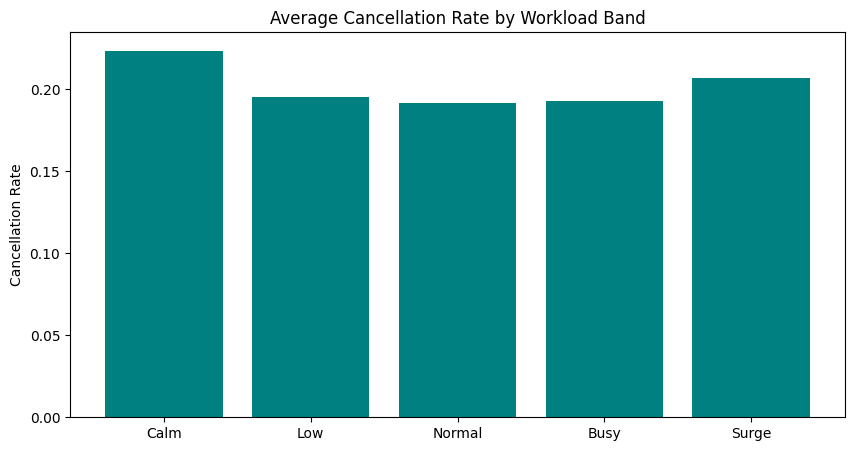

,avg_calls,avg_cancel_rate,window_count
workload_band,,,
Calm,2.883860,0.223537,32435
Low,6.025667,0.195038,40597
Normal,8.483130,0.191585,26438
Busy,10.458611,0.192588,20706
Surge,14.662344,0.207120,29228


In [3]:
agg["workload_band"] = pd.qcut(
    agg["total_calls"], 5, labels=["Calm", "Low", "Normal", "Busy", "Surge"]
)

band_summary = agg.groupby("workload_band", observed=True).agg(
    avg_calls=("total_calls", "mean"),
    avg_cancel_rate=("cancel_rate", "mean"),
    window_count=("total_calls", "count")
)

plt.figure(figsize=(10, 5))
plt.bar(band_summary.index, band_summary["avg_cancel_rate"], color="teal")
plt.title("Average Cancellation Rate by Workload Band")
plt.ylabel("Cancellation Rate")
plt.show()

display(band_summary)

## 3. Stress Analysis
Identify the most demanding windows in the dataset's history.

In [4]:
top_stress_windows = agg.sort_values("total_calls", ascending=False).head(10)
display("Top 10 High-Demand Windows:", top_stress_windows)

'Top 10 High-Demand Windows:'

,time_bin,total_calls,canceled_calls,priority_1_calls,cancel_rate,priority_1_share,workload_band
146555,2026-03-28 23:45:00,80,27,3,0.337500,0.037500,Surge
146553,2026-03-28 23:15:00,79,15,0,0.189873,0.000000,Surge
146723,2026-03-30 18:15:00,76,20,8,0.263158,0.105263,Surge
146720,2026-03-30 17:30:00,67,24,8,0.358209,0.119403,Surge
146722,2026-03-30 18:00:00,67,4,0,0.059701,0.000000,Surge
146563,2026-03-29 01:45:00,66,11,4,0.166667,0.060606,Surge
146647,2026-03-29 23:00:00,65,20,0,0.307692,0.000000,Surge
146728,2026-03-30 19:30:00,64,0,0,0.000000,0.000000,Surge
146894,2026-04-01 13:00:00,64,16,0,0.250000,0.000000,Surge
146898,2026-04-01 14:00:00,61,12,0,0.196721,0.000000,Surge
